In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from tqdm import tqdm

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset
from torch.functional import F
import sentencepiece as spm
from datasets import load_from_disk


/home/yayy/miniconda3/envs/mlai_env/lib/python3.12/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
class InputEmbedding(nn.Module):

    def __init__(self, d_model, vocab_size):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.d_model)


In [4]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, seq_length, device,dropout = 0.1):
        super().__init__()
        self.d_model = d_model
        self.seq_length = seq_length
        self.dropout = nn.Dropout(dropout)
        
        pe = torch.zeros(self.seq_length, self.d_model)
        positions = torch.arange(0, self.seq_length, dtype = torch.float).unsqueeze(1)
        
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(positions * div_term)
        pe[:, 1::2] = torch.cos(positions * div_term)
        
        pe = pe.unsqueeze(0)

        self.register_buffer('pe', pe) # By adding this in register buffer this stores pe too while saving the model without considering it as a learning parameter
                

    def forward(self, x):
        x = x + self.pe[:, :x.shape[1], :]
        return self.dropout(x)

In [5]:
class FeedForward(nn.Module):

    def __init__(self, d_model, dff, dropout = 0.1):
        super(FeedForward, self).__init__()
        self.forward1 = nn.Linear(d_model, dff)
        self.dropout = nn.Dropout(dropout)
        self.forward2 = nn.Linear(dff, d_model)

    def forward(self, x):
        return self.forward2(self.dropout(torch.relu(self.forward1(x))))

In [6]:
class MultiHeadAttention(nn.Module):

    def __init__(self, d_model, heads, device,dropout = 0.1):
        super(MultiHeadAttention, self).__init__()
        self.d_model = d_model
        self.heads = heads
        self.d_heads = d_model//heads
        self.device = device

        self.w_q = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

        self.softmax = nn.Softmax(dim = -1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_q, x_k, x_v, mask = None):
        
        batch_size, seq_len, d_model = x_q.shape

        query = self.w_q(x_q).view(batch_size, x_q.shape[1], self.heads, self.d_heads).permute(0, 2, 1, 3)
        key = self.w_k(x_k).view(batch_size, x_k.shape[1], self.heads, self.d_heads).permute(0, 2, 1, 3)
        value = self.w_v(x_v).view(batch_size, x_v.shape[1], self.heads, self.d_heads).permute(0, 2, 1, 3)

        similarity = torch.matmul(query, key.transpose(-2, -1))/math.sqrt(self.d_heads)
        if mask is not None:
            # print(mask.shape, similarity.shape)
            # mask = mask.to(self.device)
            # print(mask.shape)
            similarity = similarity.masked_fill(~mask.bool() , float('-inf'))
        sim = F.softmax(similarity, dim = -1)
        final = torch.matmul(sim, value)
        final = self.dropout(final)

        final = final.permute(0, 2, 1, 3).contiguous()
        final = final.view(batch_size, seq_len, self.d_model)
        

        return self.w_o(final)

In [7]:
class ResidualConnection(nn.Module):

    def __init__(self, d_model ,dropout):

        super(ResidualConnection, self).__init__()
        self.ln = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x1, sublayer):

        return x1 + self.dropout(sublayer(self.ln(x1)))

In [8]:
class TransformerLRScheduler:
    def __init__(self, optimizer, d_model, warmup_steps=4000):
        self.optimizer = optimizer
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.step_num = 0

    def step(self):
        self.step_num += 1
        # Calculate the learning rate based on the paper's formula
        arg1 = self.step_num ** -0.5
        arg2 = self.step_num * (self.warmup_steps ** -1.5)
        lr = (self.d_model ** -0.5) * min(arg1, arg2)
        
        # Update the learning rate in the optimizer
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr

In [9]:
class EncoderBlock(nn.Module):

    def __init__(self,  dff, d_model, heads, device,dropout):

        super(EncoderBlock, self).__init__()
        self.multi_attention = MultiHeadAttention(d_model, heads, device,dropout)
        self.residual_connections = nn.ModuleList([ResidualConnection(d_model, dropout) for _ in range(2)])

        self.feed_forward = FeedForward(d_model, dff)

    def forward(self, x, mask):

        x1 = lambda x: self.multi_attention(x, x, x, mask)
        x2 = self.residual_connections[0](x, x1)
        x4 = self.residual_connections[1](x2, self.feed_forward)
        return x4

In [10]:
class Encoder(nn.Module):

    def __init__(self, vocab_size, dff, seq_length, d_model, heads,device, dropout, n = 6):

        super(Encoder, self).__init__()

        self.embedding_layer = InputEmbedding(d_model, vocab_size)
        self.positional_encoding = PositionalEncoding(d_model, seq_length, device,dropout)
        self.ln = nn.LayerNorm(d_model)
        self.encoder_blocks = nn.ModuleList([EncoderBlock(dff, d_model, heads,device,dropout) for _ in range(n)])

    def forward(self,x_e):

        x = self.positional_encoding(self.embedding_layer(x_e))
        mask = (x_e != 0).long().unsqueeze(1).unsqueeze(2)
        for block in self.encoder_blocks:
            x = block(x, mask)
        return self.ln(x), mask

In [11]:
class DecoderBlock(nn.Module):

    def __init__(self, dff, d_model, heads, device,dropout):

        super(DecoderBlock, self).__init__()
        
        self.masked_attention = MultiHeadAttention(d_model, heads, device, dropout)
        self.residual_connections = nn.ModuleList([ResidualConnection(d_model, dropout) for _ in range(3)])
        self.cross_attention = MultiHeadAttention(d_model, heads, device, dropout)
        self.feed_forward = FeedForward(d_model, dff)


    def forward(self, x, x_enc, tgt_mask, src_mask):
        
        x1= lambda x: self.masked_attention(x, x, x, tgt_mask)
        x2 = self.residual_connections[0](x, x1)

        x3= lambda x: self.cross_attention(x, x_enc, x_enc, src_mask)
        x4 = self.residual_connections[1](x2, x3)

        x5 = self.feed_forward
        x6 = self.residual_connections[2](x4, x5)

        return x6

In [12]:
class Decoder(nn.Module):

    def __init__(self, vocab_size, dff, seq_length, d_model, heads,device ,dropout, n = 6):

        super(Decoder, self).__init__()
        
        self.embedding_layer = InputEmbedding(d_model, vocab_size)
        self.positional_encoding = PositionalEncoding(d_model, seq_length, device,dropout)

        self.decoder_blocks = nn.ModuleList([DecoderBlock(dff, d_model, heads,device, dropout) for _ in range(n)])
        self.ln = nn.LayerNorm(d_model)

        self.register_buffer("casual_mask", torch.tril(torch.ones(seq_length, seq_length)))
        self.linear = nn.Linear(d_model, vocab_size)


    def forward(self, x_d, x_enc, src_mask = None, tgt_mask = None):
        
        batch_size, seq_len = x_d.size()
        
        # Padding mask for target (ignore 0s)
        padding_mask = (x_d != 0).unsqueeze(1).unsqueeze(2) 
        
        # Look-ahead mask (triangle)
        look_ahead_mask = torch.tril(torch.ones(seq_len, seq_len)).to(x_d.device)
        
        # Combine them
        tgt_mask = padding_mask & look_ahead_mask.bool()

        # 2. Embeddings
        x = self.positional_encoding(self.embedding_layer(x_d))

        # 3. Pass masks to blocks
        for block in self.decoder_blocks:
            # src_mask comes from the function argument (from Encoder)
            x = block(x, x_enc, tgt_mask, src_mask)
            
        return self.linear(self.ln(x))

In [13]:
class MyTransformer(nn.Module):

    def __init__(self, vocab_size_source, vocab_size_target, seq_length_source, seq_length_target, device,d_model = 512, heads = 8, dropout = 0.1, dff = 2048):

        super(MyTransformer, self).__init__()

        self.encoder = Encoder(vocab_size_source, dff, seq_length_source, d_model, heads, device, dropout)
        # print(1)
        self.decoder = Decoder(vocab_size_target, dff, seq_length_target, d_model, heads, device, dropout)

        # for parameter in self.parameters():
        #     if isinstance(parameter, nn.Linear):
        #         nn.init.xavier_uniform_(parameter)

    def forward(self, x_in, x_op=None):
        x_enc, src_mask = self.encoder(x_in)
        if x_op is None:
            return x_enc, src_mask
        output = self.decoder(x_op, x_enc, src_mask)
        return output

In [14]:
from datasets import load_dataset
import string
import nltk
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk_dir = r'Dataset/'
nltk.download('stopwords', download_dir = nltk_dir)
nltk.download('wordnet', download_dir = nltk_dir)
nltk.download('punkt', download_dir = nltk_dir)
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')

[nltk_data] Downloading package stopwords to Dataset/...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to Dataset/...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to Dataset/...
[nltk_data]   Package punkt is already up-to-date!


True

In [15]:
# dataset = load_dataset("Helsinki-NLP/opus_books", 'en-es')
# dataset.save_to_disk("./my_opus_books_dataset")
# # dfff = dataset['train'].to_pandas()
# # dfff = dfff['translation']
# # df = pd.DataFrame(dfff.to_list())

# # df['len1'] = df['en'].apply(lambda x : len(x.split()))
# # df['len2'] = df['es'].apply(lambda x : len(x.split()))
# # df = df[(df['len1'] >5) & (df['len1'] <100) & (df['len2'] >5) & (df['len2'] <100)]

In [16]:
dataset = load_dataset("iamTangsang/Nepali-to-English-Translation-Dataset")
dataset.save_to_disk("./my_opus_books_dataset")
# dfff = dataset['train'].to_pandas()
# dfff = dfff['translation']
# df = pd.DataFrame(dfff.to_list())

# df['len1'] = df['en'].apply(lambda x : len(x.split()))
# df['len2'] = df['es'].apply(lambda x : len(x.split()))
# df = df[(df['len1'] >5) & (df['len1'] <100) & (df['len2'] >5) & (df['len2'] <100)]

README.md:   0%|          | 0.00/568 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/76.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.19M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/702697 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10866 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10867 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/702697 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/10866 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/10867 [00:00<?, ? examples/s]

In [14]:
from datasets import load_from_disk

dataset = load_from_disk("./my_opus_books_dataset")

print(dataset)
print((dataset["train"][0]))

df_train = pd.DataFrame(dataset['train'])
df_val_= pd.DataFrame(dataset['validation'])
df_test = pd.DataFrame(dataset['test'])


DatasetDict({
    train: Dataset({
        features: ['source', 'target'],
        num_rows: 702697
    })
    validation: Dataset({
        features: ['source', 'target'],
        num_rows: 10866
    })
    test: Dataset({
        features: ['source', 'target'],
        num_rows: 10867
    })
})
{'source': '"कुनै पनि अन्य सरकारी एजेन्सीले यो जानकारी प्रयोग गर्न सक्दैन, केन्द्रीय सरकार अन्तर्गतका कसैले कुनै पनि हालतमा यो जानकारी पाउँदैनन् र राज्यका अधिकारीहरूमा पनि स्वास्थ्य अधिकारीहरूले मात्र यसलाई प्रयोग गर्न सक्दछन्," उनले भने।', 'target': '"No other government agency can use this information, no one in the commonwealth government at all, and in state authorities, only the health officer can use it.'}


In [15]:

import re

def normalize_danda(text):
    text = text.strip()

    text = re.sub(r'\s+([।?!])', r'\1', text)
    if text and text[-1] not in '।?!.…"\'”)':
        text += '।'


    return text

In [16]:
df_train["source"] = df_train["source"].apply(lambda x: normalize_danda(x) if isinstance(x, str) else x)
df_val_["source"] = df_val_["source"].apply(lambda x: normalize_danda(x) if isinstance(x, str) else x)
df_test["source"] = df_test["source"].apply(lambda x: normalize_danda(x) if isinstance(x, str) else x)

In [17]:
df = pd.concat([df_train, df_val_, df_test], ignore_index=True)

In [18]:
df["len1"] = df['source'].apply(lambda x : len(x.split()))
df["len2"] = df['target'].apply(lambda x : len(x.split()))

In [19]:
max(df["len1"]), max(df["len2"])
min(df["len1"]), min(df["len2"])

# import matplotlib.pyplot as plt
# # plt.hist(df["len1"], bins = 100, alpha = 0.5, label = "English")
# plt.hist(df["len2"], bins = 100, alpha = 1, label = "Spanish")
# plt.xlabel("Sentence Length")
# plt.ylabel("Frequency")
# plt.title("Distribution of Sentence Lengths")
# plt.legend()

(0, 0)

In [20]:
len(df)

724430

In [21]:
df.head()
# df = df[(df['len1'] >2) & (df['len1'] <70) & (df['len2'] >2) & (df['len2'] <70)]

,source,target,len1,len2
0,"""कुनै पनि अन्य सरकारी एजेन्सीले यो जानकारी प्र...","""No other government agency can use this infor...",33,27
1,"एउटा गीत प्ले गर्नुहोस्, जुन तपाईं चाहानुहुन्छ।",Pick a song which you want.,7,6
2,"तर, तपाईं उदास हुँदा चिढिएर अझ बढी रिसाउनुहुन्...","But, when you get sad, if you are going to get...",19,24
3,जिन्दगी भनेको कुनै चलचित्र होइन।,"""Life is not a movie.",5,5
4,"त्यसपछि, म र उनीबीच केही दूरीको महसुस गरेँ।",Yet I felt there was a distance between me and...,8,11


In [22]:
df.head()

,source,target,len1,len2
0,"""कुनै पनि अन्य सरकारी एजेन्सीले यो जानकारी प्र...","""No other government agency can use this infor...",33,27
1,"एउटा गीत प्ले गर्नुहोस्, जुन तपाईं चाहानुहुन्छ।",Pick a song which you want.,7,6
2,"तर, तपाईं उदास हुँदा चिढिएर अझ बढी रिसाउनुहुन्...","But, when you get sad, if you are going to get...",19,24
3,जिन्दगी भनेको कुनै चलचित्र होइन।,"""Life is not a movie.",5,5
4,"त्यसपछि, म र उनीबीच केही दूरीको महसुस गरेँ।",Yet I felt there was a distance between me and...,8,11


In [23]:
len(df)

724430

In [24]:

# X_token = [text for tokens in df['en'] for text in tokens.split()]
# c = Counter(X_token)

In [25]:
# len(c)

In [26]:
df["len1"].mean()

np.float64(9.002437778667366)

In [27]:
df[df["len1"] < 4]

,source,target,len1,len2
5,बोन्डाउकाउ।,Bondoukou,1,1
16,हामी जनताकोबीचमा छौँ।,We are people in between.,3,5
31,लेख सूची।,Articles list.,2,2
41,पोर्ट नम्बर।,Port Number,2,2
52,अनुप्रयोग चयन गर्नुहोस्।,Select an Application,3,3
...,...,...,...,...
724370,उनी पूर्णचेतमै थिए।,He was in fully conscious.,3,5
724372,चीन नजिकै छ।,China is pretty close.,3,4
724381,धेरै कुरा हुनसक्छन्।,Many things can be.,3,4
724388,पुन: खोल्नुहोस्।,Reopen,2,1


In [28]:
df.head()

,source,target,len1,len2
0,"""कुनै पनि अन्य सरकारी एजेन्सीले यो जानकारी प्र...","""No other government agency can use this infor...",33,27
1,"एउटा गीत प्ले गर्नुहोस्, जुन तपाईं चाहानुहुन्छ।",Pick a song which you want.,7,6
2,"तर, तपाईं उदास हुँदा चिढिएर अझ बढी रिसाउनुहुन्...","But, when you get sad, if you are going to get...",19,24
3,जिन्दगी भनेको कुनै चलचित्र होइन।,"""Life is not a movie.",5,5
4,"त्यसपछि, म र उनीबीच केही दूरीको महसुस गरेँ।",Yet I felt there was a distance between me and...,8,11


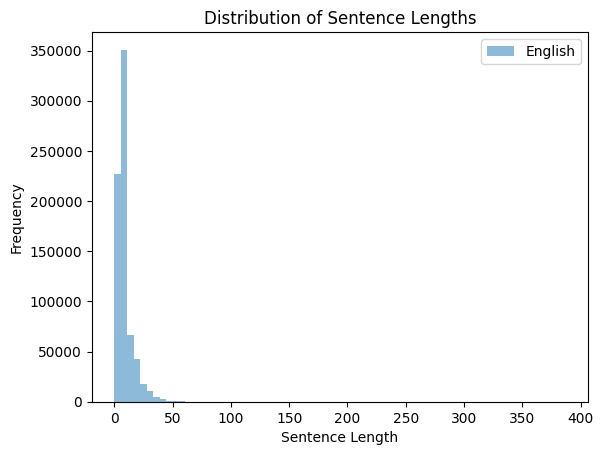

In [29]:
import matplotlib.pyplot as plt
plt.hist(df["len1"], bins = 70, alpha = 0.5, label = "English")
# plt.hist(df["len2"], bins = 70, alpha = 1, label = "Spanish")
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")
plt.title("Distribution of Sentence Lengths")
plt.legend()

In [30]:
nepali = df['source'].tolist()
english = df['target'].tolist()

with open("nepali.txt", "w", encoding = "utf-8") as f:
    for line in nepali:
        f.write(line.strip() + "\n")


with open("english.txt", "w", encoding = "utf-8") as f:
    for line in english:
        f.write(line.strip() + "\n")

In [31]:
nepali_words = len(" ".join(nepali).split())

In [32]:
nepali_words

6521636

In [33]:
import sentencepiece as spm

In [ ]:

spm.SentencePieceTrainer.train(
    input=["english.txt"], 
    model_prefix="tokenizers/english_vocab",
    vocab_size=16000,
    model_type="unigram",
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,
    pad_piece="<PAD>",
    unk_piece="<UNK>",
    bos_piece="<BOS>",
    eos_piece="<EOS>",
)

I0000 00:00:1788628435.927931 1555197 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: english.txt
  input_format: 
  model_prefix: english_vocab
  model_type: UNIGRAM
  vocab_size: 16000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <UNK>
  bos_piece: <BOS>
  eos_piece: <EOS>
  pad_piece: <PAD>
  unk_surface:  ⁇ 
  en

True

In [ ]:

spm.SentencePieceTrainer.train(
    input=["nepali.txt"], 
    model_prefix="tokenizers/nepali_vocab",
    vocab_size=16000,
    model_type="unigram",
    character_coverage=0.9995,
    byte_fallback=True,
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,
    pad_piece="<PAD>",
    unk_piece="<UNK>",
    bos_piece="<BOS>",
    eos_piece="<EOS>",
)

I0000 00:00:1788628469.270724 1555197 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: nepali.txt
  input_format: 
  model_prefix: nepali_vocab
  model_type: UNIGRAM
  vocab_size: 16000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 1
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <UNK>
  bos_piece: <BOS>
  eos_piece: <EOS>
  pad_piece: <PAD>
  unk_surface:  ⁇ 
  enab

True

In [ ]:
sp_english = spm.SentencePieceProcessor(model_file="tokenizers/english_vocab.model")
sp_nepali = spm.SentencePieceProcessor(model_file="tokenizers/nepali_vocab.model")

In [37]:
english = df["target"][999]
en_enc = sp_english.encode(english, out_type = int)

In [38]:
english

'Tell your mother and father.'

In [39]:
sp_english.decode(en_enc)

'Tell your mother and father.'

In [40]:
nepali = df["source"][88]
ne_enc = sp_nepali.encode(nepali, out_type = int)

print(nepali)

print(sp_nepali.decode(ne_enc))

यसका लागि तपाईसित के हुनु पर्छ?
यसका लागि तपाईसित के हुनु पर्छ?


In [41]:
df_train["nepali_encoded"] = df_train["source"].apply(lambda x: sp_nepali.encode(x, out_type = int) if isinstance(x, str) else x)
df_val_["nepali_encoded"] = df_val_["source"].apply(lambda x: sp_nepali.encode(x, out_type = int) if isinstance(x, str) else x)
df_test["nepali_encoded"] = df_test["source"].apply(lambda x: sp_nepali.encode(x, out_type = int) if isinstance(x, str) else x)

df_train["english_encoded"] = df_train["target"].apply(lambda x: sp_english.encode(x, out_type = int) if isinstance(x, str) else x)
df_val_["english_encoded"] = df_val_["target"].apply(lambda x: sp_english.encode(x, out_type = int) if isinstance(x, str) else x)
df_test["english_encoded"] = df_test["target"].apply(lambda x: sp_english.encode(x, out_type = int) if isinstance(x, str) else x)

In [42]:
df_train.head()

,source,target,nepali_encoded,english_encoded
0,"""कुनै पनि अन्य सरकारी एजेन्सीले यो जानकारी प्र...","""No other government agency can use this infor...","[330, 4625, 266, 367, 914, 4647, 272, 264, 535...","[38, 2581, 76, 156, 3680, 53, 157, 25, 320, 6,..."
1,"एउटा गीत प्ले गर्नुहोस्, जुन तपाईं चाहानुहुन्छ।",Pick a song which you want.,"[298, 617, 1833, 299, 262, 360, 322, 1796, 260]","[6446, 12, 458, 83, 18, 119, 4]"
2,"तर, तपाईं उदास हुँदा चिढिएर अझ बढी रिसाउनुहुन्...","But, when you get sad, if you are going to get...","[286, 262, 322, 6770, 783, 2392, 2400, 2558, 8...","[75, 6, 107, 18, 163, 1628, 6, 133, 18, 16, 13..."
3,जिन्दगी भनेको कुनै चलचित्र होइन।,"""Life is not a movie.","[3112, 454, 297, 1001, 337, 260]","[38, 11628, 9, 20, 12, 356, 4]"
4,"त्यसपछि, म र उनीबीच केही दूरीको महसुस गरेँ।",Yet I felt there was a distance between me and...,"[423, 262, 278, 265, 281, 1214, 302, 3911, 263...","[1798, 15, 811, 70, 14, 12, 2170, 176, 58, 10,..."


In [43]:
print(df_train["source"].apply(len)[32], len(df_train["nepali_encoded"][32]))

48 10


In [44]:
i = 32
print(df_train["source"][i])
print(df_train["nepali_encoded"][i])

यदि हो भने पुलिसलाई नै पक्रन चाहिँ कसलाई पठाउने?
[342, 268, 280, 6450, 289, 7478, 1831, 2324, 3562, 282]


In [45]:
len(df_train)

702697

In [46]:
max_len_train = 64
max_len_val_test = 64

df_train = df_train[(df_train["english_encoded"].apply(len) <= max_len_train - 1) & (df_train["nepali_encoded"].apply(len) <= max_len_train - 1)]
df_val = df_val_[(df_val_["english_encoded"].apply(len) <= max_len_val_test - 1) & (df_val_["nepali_encoded"].apply(len) <= max_len_val_test - 1)]
df_test = df_test[(df_test["english_encoded"].apply(len) <= max_len_val_test - 1) & (df_test["nepali_encoded"].apply(len) <= max_len_val_test - 1)]

In [47]:
len(df_train), len(df_val), len(df_test)

(699156, 10815, 10812)

In [48]:
len(df_train[df_train["english_encoded"].apply(len) > max_len_train - 1])
len(df_val[df_val["english_encoded"].apply(len) > max_len_val_test - 1])
len(df_test[df_test["english_encoded"].apply(len) > max_len_val_test - 1])

0

In [49]:
df_train.head()

,source,target,nepali_encoded,english_encoded
0,"""कुनै पनि अन्य सरकारी एजेन्सीले यो जानकारी प्र...","""No other government agency can use this infor...","[330, 4625, 266, 367, 914, 4647, 272, 264, 535...","[38, 2581, 76, 156, 3680, 53, 157, 25, 320, 6,..."
1,"एउटा गीत प्ले गर्नुहोस्, जुन तपाईं चाहानुहुन्छ।",Pick a song which you want.,"[298, 617, 1833, 299, 262, 360, 322, 1796, 260]","[6446, 12, 458, 83, 18, 119, 4]"
2,"तर, तपाईं उदास हुँदा चिढिएर अझ बढी रिसाउनुहुन्...","But, when you get sad, if you are going to get...","[286, 262, 322, 6770, 783, 2392, 2400, 2558, 8...","[75, 6, 107, 18, 163, 1628, 6, 133, 18, 16, 13..."
3,जिन्दगी भनेको कुनै चलचित्र होइन।,"""Life is not a movie.","[3112, 454, 297, 1001, 337, 260]","[38, 11628, 9, 20, 12, 356, 4]"
4,"त्यसपछि, म र उनीबीच केही दूरीको महसुस गरेँ।",Yet I felt there was a distance between me and...,"[423, 262, 278, 265, 281, 1214, 302, 3911, 263...","[1798, 15, 811, 70, 14, 12, 2170, 176, 58, 10,..."


In [50]:
df_val_.head()

,source,target,nepali_encoded,english_encoded
0,राम्रो साथीले तपाईंको सबै कथाहरू जान्दछ।,A good friend is aware of all your stories.,"[352, 9494, 366, 291, 3970, 8721, 260]","[109, 123, 640, 9, 894, 8, 40, 49, 1229, 4]"
1,उक्त युवती के कारणले सो जङ्गलमा गएकी हुन् वा आ...,Police have begun probe into the matter to kno...,"[501, 2822, 313, 784, 638, 6621, 267, 4374, 32...","[1247, 27, 2562, 12609, 137, 5, 578, 7, 60, 65..."
2,यस्तो देखिन्छ कि नरड खेल यूरोपमा अरबीहरू द्वार...,It seems that the Nard game was introduced in ...,"[369, 742, 305, 6495, 741, 405, 3990, 267, 891...","[31, 1060, 19, 5, 6890, 122, 173, 14, 2657, 11..."
3,पाँच वर्षपछि मुद्दा फैसला भएको हो।,Now 5 years later the issue is resolved.,"[621, 1560, 1583, 2698, 279, 268, 260]","[214, 298, 68, 388, 5, 447, 9, 4237, 4]"
4,- ए त्यसो भए तिमी एक्लै हो अहिले?,And now that you're alone?,"[412, 898, 834, 376, 599, 1834, 268, 323, 282]","[144, 81, 19, 18, 23, 177, 673, 39]"


In [51]:
df_test.head()

,source,target,nepali_encoded,english_encoded
0,यसबाट युवकहरु पनि पीडित भएको देखिन्छन।,Young people also suffer from it.,"[967, 4622, 347, 266, 2297, 279, 742, 326, 260]","[5645, 62, 30, 1999, 37, 24, 4]"
1,बजाऊने लिस्ट।,Playlist,"[3096, 2237, 769, 8835, 260]",[8854]
2,त्यहाँ केही नियमहरू छन् जुन तपाईंले पछ्याउनु प...,There are a few rules that you should follow:,"[363, 302, 2078, 274, 360, 417, 5386, 442, 408...","[59, 16, 12, 237, 654, 19, 18, 138, 747, 50]"
3,सबै गीतहरु उनी आफैंले लेखेका हुन्।,All songs were written by himself.,"[291, 6688, 281, 3432, 1318, 329, 260]","[231, 873, 52, 329, 51, 531, 4]"
4,मेरो एउटा जर्मन साथी छ।,I had a German friend.,"[294, 298, 3779, 986, 261, 260]","[15, 63, 12, 2572, 640, 4]"


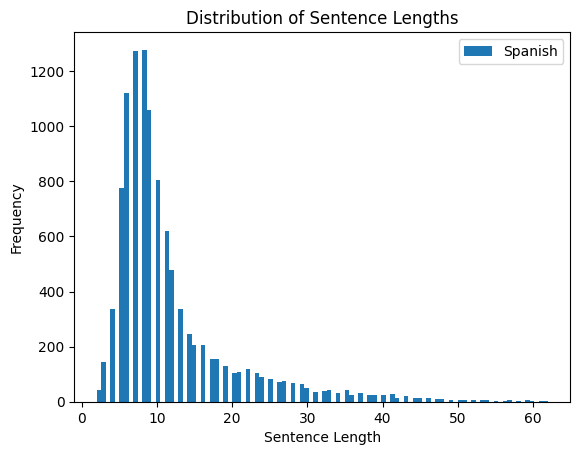

In [52]:
import matplotlib.pyplot as plt
# plt.hist(df["en_encoded"].apply(len), bins = 100, alpha = 0.5, label = "English")
plt.hist(df_val["nepali_encoded"].apply(len), bins = 100, alpha = 1, label = "Spanish")
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")
plt.title("Distribution of Sentence Lengths")
plt.legend()

In [53]:
# df['en_encoded'] = df['en'].apply(lambda x: sp.encode(x, out_type=int))
# df['es_encoded'] = df['es'].apply(lambda x: sp.encode(x, out_type=int))

In [54]:
# df = df[(df["en_encoded"].apply(len) <= 127) & (df["es_encoded"].apply(len) <= 127)]

In [55]:
len(df)

724430

In [57]:
df_val_.head()

,source,target,nepali_encoded,english_encoded
0,राम्रो साथीले तपाईंको सबै कथाहरू जान्दछ।,A good friend is aware of all your stories.,"[352, 9494, 366, 291, 3970, 8721, 260]","[109, 123, 640, 9, 894, 8, 40, 49, 1229, 4]"
1,उक्त युवती के कारणले सो जङ्गलमा गएकी हुन् वा आ...,Police have begun probe into the matter to kno...,"[501, 2822, 313, 784, 638, 6621, 267, 4374, 32...","[1247, 27, 2562, 12609, 137, 5, 578, 7, 60, 65..."
2,यस्तो देखिन्छ कि नरड खेल यूरोपमा अरबीहरू द्वार...,It seems that the Nard game was introduced in ...,"[369, 742, 305, 6495, 741, 405, 3990, 267, 891...","[31, 1060, 19, 5, 6890, 122, 173, 14, 2657, 11..."
3,पाँच वर्षपछि मुद्दा फैसला भएको हो।,Now 5 years later the issue is resolved.,"[621, 1560, 1583, 2698, 279, 268, 260]","[214, 298, 68, 388, 5, 447, 9, 4237, 4]"
4,- ए त्यसो भए तिमी एक्लै हो अहिले?,And now that you're alone?,"[412, 898, 834, 376, 599, 1834, 268, 323, 282]","[144, 81, 19, 18, 23, 177, 673, 39]"


In [58]:
max_len = 64

In [59]:
len(df_val_), len(df_test)

(10866, 10812)

In [60]:
# df_val = df_val_[(df_val_["english_encoded"].apply(len) <= 127) & (df_val_["nepali_encoded"].apply(len) <= 127)]
# df_test = df_test[(df_test["english_encoded"].apply(len) <= 127) & (df_test["nepali_encoded"].apply(len) <= 127)]

In [61]:
df_train['english_encoded_pad'] = df_train['english_encoded'].apply(lambda x: x + [3] + [0] * (max_len_train-len(x)-1))
df_train['nepali_encoded_pad'] = df_train['nepali_encoded'].apply(lambda x: [2] + x + [0] * (max_len_train-len(x)-1))
df_train['nepali_target'] = df_train['nepali_encoded'].apply(lambda x: x + [3] + [0] * (max_len_train-len(x)-1))

In [62]:

df_test['english_encoded_pad'] = df_test['english_encoded'].apply(lambda x: x + [3] + [0] * (max_len_val_test-len(x)-1))
df_test['nepali_encoded_pad'] = df_test['nepali_encoded'].apply(lambda x: [2] + x + [0] * (max_len_val_test-len(x)-1))
df_test['nepali_target'] = df_test['nepali_encoded'].apply(lambda x: x + [3] + [0] * (max_len_val_test-len(x)-1))

df_val['english_encoded_pad'] = df_val['english_encoded'].apply(lambda x: x + [3] + [0] * (max_len_val_test-len(x)-1))
df_val['nepali_encoded_pad'] = df_val['nepali_encoded'].apply(lambda x: [2] + x + [0] * (max_len_val_test-len(x)-1))
df_val['nepali_target'] = df_val['nepali_encoded'].apply(lambda x: x + [3] + [0] * (max_len_val_test-len(x)-1))   

In [63]:
len(df_val_), len(df_test)

(10866, 10812)

In [64]:
df.head()

,source,target,len1,len2
0,"""कुनै पनि अन्य सरकारी एजेन्सीले यो जानकारी प्र...","""No other government agency can use this infor...",33,27
1,"एउटा गीत प्ले गर्नुहोस्, जुन तपाईं चाहानुहुन्छ।",Pick a song which you want.,7,6
2,"तर, तपाईं उदास हुँदा चिढिएर अझ बढी रिसाउनुहुन्...","But, when you get sad, if you are going to get...",19,24
3,जिन्दगी भनेको कुनै चलचित्र होइन।,"""Life is not a movie.",5,5
4,"त्यसपछि, म र उनीबीच केही दूरीको महसुस गरेँ।",Yet I felt there was a distance between me and...,8,11


In [65]:
df_train.head()

,source,target,nepali_encoded,english_encoded,english_encoded_pad,nepali_encoded_pad,nepali_target
0,"""कुनै पनि अन्य सरकारी एजेन्सीले यो जानकारी प्र...","""No other government agency can use this infor...","[330, 4625, 266, 367, 914, 4647, 272, 264, 535...","[38, 2581, 76, 156, 3680, 53, 157, 25, 320, 6,...","[38, 2581, 76, 156, 3680, 53, 157, 25, 320, 6,...","[2, 330, 4625, 266, 367, 914, 4647, 272, 264, ...","[330, 4625, 266, 367, 914, 4647, 272, 264, 535..."
1,"एउटा गीत प्ले गर्नुहोस्, जुन तपाईं चाहानुहुन्छ।",Pick a song which you want.,"[298, 617, 1833, 299, 262, 360, 322, 1796, 260]","[6446, 12, 458, 83, 18, 119, 4]","[6446, 12, 458, 83, 18, 119, 4, 3, 0, 0, 0, 0,...","[2, 298, 617, 1833, 299, 262, 360, 322, 1796, ...","[298, 617, 1833, 299, 262, 360, 322, 1796, 260..."
2,"तर, तपाईं उदास हुँदा चिढिएर अझ बढी रिसाउनुहुन्...","But, when you get sad, if you are going to get...","[286, 262, 322, 6770, 783, 2392, 2400, 2558, 8...","[75, 6, 107, 18, 163, 1628, 6, 133, 18, 16, 13...","[75, 6, 107, 18, 163, 1628, 6, 133, 18, 16, 13...","[2, 286, 262, 322, 6770, 783, 2392, 2400, 2558...","[286, 262, 322, 6770, 783, 2392, 2400, 2558, 8..."
3,जिन्दगी भनेको कुनै चलचित्र होइन।,"""Life is not a movie.","[3112, 454, 297, 1001, 337, 260]","[38, 11628, 9, 20, 12, 356, 4]","[38, 11628, 9, 20, 12, 356, 4, 3, 0, 0, 0, 0, ...","[2, 3112, 454, 297, 1001, 337, 260, 0, 0, 0, 0...","[3112, 454, 297, 1001, 337, 260, 3, 0, 0, 0, 0..."
4,"त्यसपछि, म र उनीबीच केही दूरीको महसुस गरेँ।",Yet I felt there was a distance between me and...,"[423, 262, 278, 265, 281, 1214, 302, 3911, 263...","[1798, 15, 811, 70, 14, 12, 2170, 176, 58, 10,...","[1798, 15, 811, 70, 14, 12, 2170, 176, 58, 10,...","[2, 423, 262, 278, 265, 281, 1214, 302, 3911, ...","[423, 262, 278, 265, 281, 1214, 302, 3911, 263..."


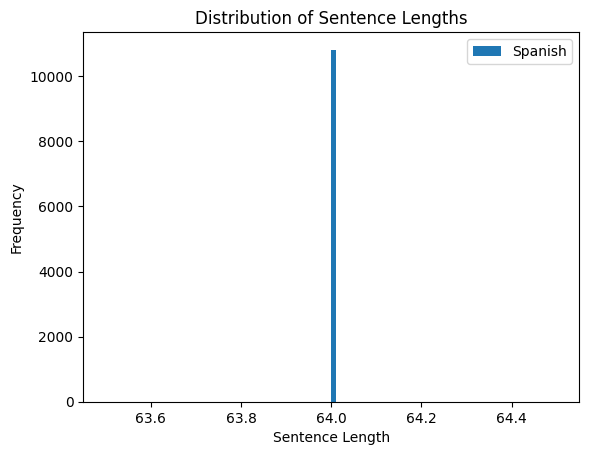

In [66]:
import matplotlib.pyplot as plt
# plt.hist(df["en_encoded"].apply(len), bins = 100, alpha = 0.5, label = "English")
plt.hist(df_val["english_encoded_pad"].apply(len), bins = 100, alpha = 1, label = "Spanish")
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")
plt.title("Distribution of Sentence Lengths")
plt.legend()

In [67]:
# BATCH_SIZE = 32

# source_tensor_encoder = torch.tensor(df['en_encoded_pad'].tolist(), dtype=torch.long)
# target_tensor_decoder = torch.tensor(df['es_encoded_pad'].tolist(), dtype=torch.long)
# output_tensor = torch.tensor(df['es_target'].tolist(), dtype=torch.long)

# train_dataset = TensorDataset(source_tensor_encoder, target_tensor_decoder, output_tensor)

# total = len(df)
# train = int(0.9 * total)
# test_val = total - train
# val = int(0.5 * test_val)
# test = test_val - val

# train_dataset, val_dataset, test_dataset = random_split(train_dataset, [train, val, test])
# train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
# val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
# test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)


In [68]:
df_train.head()

,source,target,nepali_encoded,english_encoded,english_encoded_pad,nepali_encoded_pad,nepali_target
0,"""कुनै पनि अन्य सरकारी एजेन्सीले यो जानकारी प्र...","""No other government agency can use this infor...","[330, 4625, 266, 367, 914, 4647, 272, 264, 535...","[38, 2581, 76, 156, 3680, 53, 157, 25, 320, 6,...","[38, 2581, 76, 156, 3680, 53, 157, 25, 320, 6,...","[2, 330, 4625, 266, 367, 914, 4647, 272, 264, ...","[330, 4625, 266, 367, 914, 4647, 272, 264, 535..."
1,"एउटा गीत प्ले गर्नुहोस्, जुन तपाईं चाहानुहुन्छ।",Pick a song which you want.,"[298, 617, 1833, 299, 262, 360, 322, 1796, 260]","[6446, 12, 458, 83, 18, 119, 4]","[6446, 12, 458, 83, 18, 119, 4, 3, 0, 0, 0, 0,...","[2, 298, 617, 1833, 299, 262, 360, 322, 1796, ...","[298, 617, 1833, 299, 262, 360, 322, 1796, 260..."
2,"तर, तपाईं उदास हुँदा चिढिएर अझ बढी रिसाउनुहुन्...","But, when you get sad, if you are going to get...","[286, 262, 322, 6770, 783, 2392, 2400, 2558, 8...","[75, 6, 107, 18, 163, 1628, 6, 133, 18, 16, 13...","[75, 6, 107, 18, 163, 1628, 6, 133, 18, 16, 13...","[2, 286, 262, 322, 6770, 783, 2392, 2400, 2558...","[286, 262, 322, 6770, 783, 2392, 2400, 2558, 8..."
3,जिन्दगी भनेको कुनै चलचित्र होइन।,"""Life is not a movie.","[3112, 454, 297, 1001, 337, 260]","[38, 11628, 9, 20, 12, 356, 4]","[38, 11628, 9, 20, 12, 356, 4, 3, 0, 0, 0, 0, ...","[2, 3112, 454, 297, 1001, 337, 260, 0, 0, 0, 0...","[3112, 454, 297, 1001, 337, 260, 3, 0, 0, 0, 0..."
4,"त्यसपछि, म र उनीबीच केही दूरीको महसुस गरेँ।",Yet I felt there was a distance between me and...,"[423, 262, 278, 265, 281, 1214, 302, 3911, 263...","[1798, 15, 811, 70, 14, 12, 2170, 176, 58, 10,...","[1798, 15, 811, 70, 14, 12, 2170, 176, 58, 10,...","[2, 423, 262, 278, 265, 281, 1214, 302, 3911, ...","[423, 262, 278, 265, 281, 1214, 302, 3911, 263..."


In [69]:
df_test.head()

,source,target,nepali_encoded,english_encoded,english_encoded_pad,nepali_encoded_pad,nepali_target
0,यसबाट युवकहरु पनि पीडित भएको देखिन्छन।,Young people also suffer from it.,"[967, 4622, 347, 266, 2297, 279, 742, 326, 260]","[5645, 62, 30, 1999, 37, 24, 4]","[5645, 62, 30, 1999, 37, 24, 4, 3, 0, 0, 0, 0,...","[2, 967, 4622, 347, 266, 2297, 279, 742, 326, ...","[967, 4622, 347, 266, 2297, 279, 742, 326, 260..."
1,बजाऊने लिस्ट।,Playlist,"[3096, 2237, 769, 8835, 260]",[8854],"[8854, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2, 3096, 2237, 769, 8835, 260, 0, 0, 0, 0, 0,...","[3096, 2237, 769, 8835, 260, 3, 0, 0, 0, 0, 0,..."
2,त्यहाँ केही नियमहरू छन् जुन तपाईंले पछ्याउनु प...,There are a few rules that you should follow:,"[363, 302, 2078, 274, 360, 417, 5386, 442, 408...","[59, 16, 12, 237, 654, 19, 18, 138, 747, 50]","[59, 16, 12, 237, 654, 19, 18, 138, 747, 50, 3...","[2, 363, 302, 2078, 274, 360, 417, 5386, 442, ...","[363, 302, 2078, 274, 360, 417, 5386, 442, 408..."
3,सबै गीतहरु उनी आफैंले लेखेका हुन्।,All songs were written by himself.,"[291, 6688, 281, 3432, 1318, 329, 260]","[231, 873, 52, 329, 51, 531, 4]","[231, 873, 52, 329, 51, 531, 4, 3, 0, 0, 0, 0,...","[2, 291, 6688, 281, 3432, 1318, 329, 260, 0, 0...","[291, 6688, 281, 3432, 1318, 329, 260, 3, 0, 0..."
4,मेरो एउटा जर्मन साथी छ।,I had a German friend.,"[294, 298, 3779, 986, 261, 260]","[15, 63, 12, 2572, 640, 4]","[15, 63, 12, 2572, 640, 4, 3, 0, 0, 0, 0, 0, 0...","[2, 294, 298, 3779, 986, 261, 260, 0, 0, 0, 0,...","[294, 298, 3779, 986, 261, 260, 3, 0, 0, 0, 0,..."


In [70]:
BATCH_SIZE = 32

source_tensor_encoder_train = torch.tensor(df_train['english_encoded_pad'].tolist(), dtype=torch.long)
target_tensor_decoder_train = torch.tensor(df_train['nepali_encoded_pad'].tolist(), dtype=torch.long)
output_tensor_train = torch.tensor(df_train['nepali_target'].tolist(), dtype=torch.long)

source_tensor_encoder_test = torch.tensor(df_test['english_encoded_pad'].tolist(), dtype=torch.long)
target_tensor_decoder_test = torch.tensor(df_test['nepali_encoded_pad'].tolist(), dtype=torch.long)
output_tensor_test = torch.tensor(df_test['nepali_target'].tolist(), dtype=torch.long)

source_tensor_encoder_val = torch.tensor(df_val['english_encoded_pad'].tolist(), dtype=torch.long)
target_tensor_decoder_val = torch.tensor(df_val['nepali_encoded_pad'].tolist(), dtype=torch.long)
output_tensor_val = torch.tensor(df_val['nepali_target'].tolist(), dtype=torch.long)

train_dataset = TensorDataset(source_tensor_encoder_train, target_tensor_decoder_train, output_tensor_train)
test_dataset = TensorDataset(source_tensor_encoder_test, target_tensor_decoder_test, output_tensor_test)
val_dataset = TensorDataset(source_tensor_encoder_val, target_tensor_decoder_val, output_tensor_val)

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)


In [ ]:
# train script
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

def train(epochs, train_loader, val_loader, vocab_size_source, vocab_size_target, max_len_train, max_len_val_test, sp_english, sp_nepali):

    seq_length_source = max_len_train
    seq_length_target = max_len_train

    d_model = 512
    heads = 8
    dropout = 0.1
    dff = 2048

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(device)
    model = MyTransformer(
        vocab_size_source, vocab_size_target,
        seq_length_source, seq_length_target,
        device, d_model, heads, dropout, dff
    ).to(device)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params}")


    optimizer = torch.optim.Adam(model.parameters(), lr=0.0, betas=(0.9, 0.98), eps=1e-9)
    scheduler = TransformerLRScheduler(optimizer, d_model=512, warmup_steps=4000)
    criteria = nn.CrossEntropyLoss(ignore_index=0)


    def init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0, std=0.02)
            
    model.apply(init_weights)

    def beam_search_decode(source, beam_size=4):
        source = source[:1].to(device)

        src_enc, src_mask = model.encoder(source)
        
        beam_probs = torch.full((beam_size, 1), -1e9).to(device)
        beam_probs[0] = 0.0
        beam_seq = torch.full((beam_size, 1), 2, dtype=torch.long).to(device)

        with torch.no_grad():
            src_enc_repeat = src_enc.repeat_interleave(beam_size, dim=0)
            src_mask_repeat = src_mask.repeat_interleave(beam_size, dim=0)

            for step in range(max_len_train):
                output = model.decoder(beam_seq, src_enc_repeat, src_mask_repeat)
                output = output[:, -1, :]

                prob_of_last_token = torch.log_softmax(output, dim=-1)
                is_finished = beam_seq[:, -1] == 3

                if is_finished.all():
                    break
                
                if is_finished.any():
                    prob_of_last_token[is_finished, :] = -float('inf')
                    prob_of_last_token[is_finished, 3] = 0.0
                
                current_token_probs = beam_probs + prob_of_last_token
                top_probs, top_tokens = torch.topk(current_token_probs.view(-1), k=beam_size, dim=-1)

                beam_indices = top_tokens // vocab_size_target
                token_ids = top_tokens % vocab_size_target

                beam_indices_expanded = beam_indices.unsqueeze(1).expand(-1, beam_seq.size(1))
                beam_seq = torch.gather(beam_seq, 0, beam_indices_expanded)
                beam_seq = torch.cat([beam_seq, token_ids.unsqueeze(1)], dim=1)
                beam_probs = top_probs.unsqueeze(1)

        best_idx = torch.argmax(beam_probs)
        best_seq = beam_seq[best_idx]
        token_list = best_seq.tolist()
        clean_tokens = [tok for tok in token_list if tok not in [1, 2, 3]]
        
        
        final_translation = sp_nepali.decode(clean_tokens)

        source_tokens = [tok for tok in source[0].tolist() if tok not in [0, 1, 2, 3]]
        source_words = sp_english.decode(source_tokens)
        print(f"ORIGINAL ENGLISH: {source_words}")
        print(f"PREDICTED NEPALI: {final_translation}")
        print("-" * 80)


    def validation(val_loader, epoch):
        model.eval()
        val_loss = 0
        
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Validation]", leave=False)

        with torch.no_grad():
            for i, (source, target_ip, target_op) in enumerate(val_bar):
                source = source.to(device)
                target_ip = target_ip.to(device)
                target_op = target_op.to(device)

                output = model(source, target_ip)
                output = output.reshape(-1, output.size(-1))
                target_op = target_op.reshape(-1)

                loss = criteria(output, target_op)
                val_loss += loss.item()
                
                val_bar.set_postfix(loss=f"{val_loss / (i+1):.4f}")
                
                if i < 4:
                    print(f"Beam Search Sample {i+1}:")
                    beam_search_decode(source)

        return val_loss / len(val_loader)


    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        train_loss = 0
        model.train()
        
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]", leave=False)
        
        for i, (source, target_ip, target_op) in enumerate(train_bar):
            source = source.to(device)
            target_ip = target_ip.to(device)
            target_op = target_op.to(device)

            optimizer.zero_grad()
            output = model(source, target_ip)
            
            output = output.reshape(-1, output.size(-1))
            target_op = target_op.reshape(-1)

            loss = criteria(output, target_op)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()
            
            train_bar.set_postfix(loss=f"{train_loss / (i+1):.4f}")

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = validation(val_loader, epoch)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        
        print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        # Save checkpoint after every epoch
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_step_num': scheduler.step_num,
            'history': history
        }
        torch.save(checkpoint, 'checkpoints/transformer_nepali_checkpoint.pth')
        
    return history, model, optimizer, scheduler


In [74]:

VOCAB_SIZE_SOURCE = sp_english.vocab_size()
VOCAB_SIZE_TARGET = sp_nepali.vocab_size()
trained_model = train(epochs=50, train_loader=train_loader, val_loader=val_loader, vocab_size_source = VOCAB_SIZE_SOURCE, vocab_size_target = VOCAB_SIZE_TARGET, max_len_train = max_len_train, max_len_val_test = max_len_val_test, sp_english = sp_english, sp_nepali = sp_nepali)

cuda
Total parameters: 68732544


Epoch 1/50 [Training]:   0%|          | 0/21849 [00:00<?, ?it/s]

Epoch 1/50 [Validation]:   0%|          | 0/338 [00:00<?, ?it/s]

Beam Search Sample 1:
ORIGINAL ENGLISH: That followed four straight months in which the number of increases trailed the year-earlier pace .
PREDICTED NEPALI: यस वर्षको अवधिमा चार वर्षको अवधिमा चार वर्षको अवधिमा ४.६ प्रतिशतले बढिरहेको छ।
--------------------------------------------------------------------------------
Beam Search Sample 2:
ORIGINAL ENGLISH: By the way, it will not be wrong to say that computer has made the life of us very comfortable with the help of its incredible speed, accuracy and storage.
PREDICTED NEPALI: यो तरिका हो, तर हाम्रो जीवनको बारेमा सही हुन सक्छ, जुन हामीले चाहेको कुरा होइन।
--------------------------------------------------------------------------------
Beam Search Sample 3:
ORIGINAL ENGLISH: But the Levites were not numbered among the children of Israel; as Yahweh commanded Moses.
PREDICTED NEPALI: तर परमप्रभुले मोशालाई भन्नुभयो, “यदि इस्राएलका मानिसहरू इस्राएलका परमप्रभु इस्राएलका परमप्रभु इस्राएलका परमप्रभु इस्राएलका परमप्रभु इस्राएलका परमप्रभु इस्राएल

Epoch 2/50 [Training]:   0%|          | 0/21849 [00:00<?, ?it/s]

...

Epoch 49/50 [Validation]:   0%|          | 0/338 [00:00<?, ?it/s]

Beam Search Sample 1:
ORIGINAL ENGLISH: I was not potent.
PREDICTED NEPALI: म ऋण थिएन।
--------------------------------------------------------------------------------
Beam Search Sample 2:
ORIGINAL ENGLISH: Yanji
PREDICTED NEPALI: याइजी।
--------------------------------------------------------------------------------
Beam Search Sample 3:
ORIGINAL ENGLISH: While many newsrooms in the English-language world debated whether or not to reprint the US president's expletive, journalists working in other languages struggled to properly translate the word "shithole".
PREDICTED NEPALI: विश्वका धेरै शौचालयहरू अंग्रेजी वा राष्ट्रपतिलाई पुनः अनुवाद गर्ने कि नगर्ने भन्ने विषयमा छलफल गर्दा अमेरिकी पत्रकारले सही भाषा अनुवाद गर्ने काममा संघर्ष गरिरहेका छन्।
--------------------------------------------------------------------------------
Beam Search Sample 4:
ORIGINAL ENGLISH: We have been winning awards every year.
PREDICTED NEPALI: हामीले हरेक वर्ष पुरस्कार जितेका छौं।
------------------------------

Epoch 50/50 [Training]:   0%|          | 0/21849 [00:00<?, ?it/s]

Epoch 50/50 [Validation]:   0%|          | 0/338 [00:00<?, ?it/s]

Beam Search Sample 1:
ORIGINAL ENGLISH: We need to move to another level.
PREDICTED NEPALI: हामीले अर्को स्तरमा जानु पर्छ।
--------------------------------------------------------------------------------
Beam Search Sample 2:
ORIGINAL ENGLISH: And are not his sisters here before us?
PREDICTED NEPALI: अनि के उहाँका चेलाहरू यहाँ हामीसंग छैनन्?
--------------------------------------------------------------------------------
Beam Search Sample 3:
ORIGINAL ENGLISH: not going to fight about it.
PREDICTED NEPALI: यसका लागि संघर्ष गर्नु पर्दैन।
--------------------------------------------------------------------------------
Beam Search Sample 4:
ORIGINAL ENGLISH: Khashoggi for decades was close to the Saudi royal family and also served as an adviser to the government.
PREDICTED NEPALI: दशकौँदेखि साउदी राजपरिवारको निकट रहेको र सरकारको सल्लाहकारका रूपमा पनि उनले काम गरेका थिए।
--------------------------------------------------------------------------------
Epoch 50/50 | Train Loss: 2.4501 | Val 

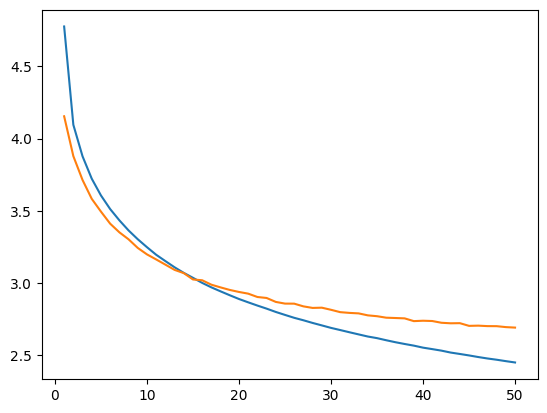

In [81]:
# trained_model[0]["train_loss"]

plt.plot(range(1, 51), trained_model[0]["train_loss"])
plt.plot(range(1, 51), trained_model[0]["val_loss"])

In [88]:
trained_model[1]

MyTransformer(
  (encoder): Encoder(
    (embedding_layer): InputEmbedding(
      (embedding): Embedding(16000, 512)
    )
    (positional_encoding): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (ln): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
    (encoder_blocks): ModuleList(
      (0-5): 6 x EncoderBlock(
        (multi_attention): MultiHeadAttention(
          (w_q): Linear(in_features=512, out_features=512, bias=True)
          (w_v): Linear(in_features=512, out_features=512, bias=True)
          (w_k): Linear(in_features=512, out_features=512, bias=True)
          (w_o): Linear(in_features=512, out_features=512, bias=True)
          (softmax): Softmax(dim=-1)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (residual_connections): ModuleList(
          (0-1): 2 x ResidualConnection(
            (ln): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
            (dropout): Dropout(p=0.1, inplac

In [96]:
def beam_search_decode(model, source, device, vocab_size_target,beam_size=4):
    src_enc, src_mask = model.encoder(source)
    
    beam_probs = torch.full((beam_size, 1), -1e9).to(device)
    beam_probs[0] = 0.0
    beam_seq = torch.full((beam_size, 1), 2, dtype=torch.long).to(device)

    with torch.no_grad():
        src_enc_repeat = src_enc.repeat_interleave(beam_size, dim=0)
        src_mask_repeat = src_mask.repeat_interleave(beam_size, dim=0)

        for step in range(max_len_train):
            output = model.decoder(beam_seq, src_enc_repeat, src_mask_repeat)
            output = output[:, -1, :]

            prob_of_last_token = torch.log_softmax(output, dim=-1)
            is_finished = beam_seq[:, -1] == 3

            if is_finished.all():
                break
            
            if is_finished.any():
                prob_of_last_token[is_finished, :] = -float('inf')
                prob_of_last_token[is_finished, 3] = 0.0
            
            current_token_probs = beam_probs + prob_of_last_token
            top_probs, top_tokens = torch.topk(current_token_probs.view(-1), k=beam_size, dim=-1)

            beam_indices = top_tokens // vocab_size_target
            token_ids = top_tokens % vocab_size_target

            beam_indices_expanded = beam_indices.unsqueeze(1).expand(-1, beam_seq.size(1))
            beam_seq = torch.gather(beam_seq, 0, beam_indices_expanded)
            beam_seq = torch.cat([beam_seq, token_ids.unsqueeze(1)], dim=1)
            beam_probs = top_probs.unsqueeze(1)

    best_idx = torch.argmax(beam_probs)
    best_seq = beam_seq[best_idx]
    token_list = best_seq.tolist()
    clean_tokens = [tok for tok in token_list if tok not in [1, 2, 3]]
    
    
    final_translation = sp_nepali.decode(clean_tokens)

    return final_translation


In [97]:
# !pip install sacrebleu

In [104]:
import sacrebleu
import torch

def evaluate_translations(model, data_loader, sp_source, sp_nepali, device, 
                           beam_search, max_len=64):

    model.eval()
    hypotheses = []
    references = []

    with torch.no_grad():
        for idx, (source, target_input, target_text) in enumerate(data_loader):
            source = source.to(device)

            for i in range(source.size(0)):
                single_source = source[i].unsqueeze(0)
                prediction_text = beam_search(model, single_source, device, sp_nepali.vocab_size())

                target_tokens = [tok for tok in target_text[i].tolist() if tok not in [0, 1, 2, 3]]
                target_text_decoded = sp_nepali.decode(target_tokens)

                hypotheses.append(prediction_text)
                references.append(sp_nepali.decode(target_text_decoded))


    bleu = sacrebleu.corpus_bleu(hypotheses, [references], tokenize='intl')
    chrf = sacrebleu.corpus_chrf(hypotheses, [references])

    print(f"Evaluated on {len(hypotheses)} sentences")
    print(f"BLEU:  {bleu.score:.2f}")
    print(f"chrF:  {chrf.score:.2f}")

    return {
        'bleu': bleu.score,
        'chrf': chrf.score,
        'hypotheses': hypotheses,
        'references': references
    }

In [105]:
results = evaluate_translations(
    model=trained_model[1],
    data_loader=test_loader,
    sp_source=sp_english,
    sp_nepali=sp_nepali,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    beam_search=beam_search_decode,
    max_len=64
)

Evaluated on 10812 sentences
BLEU:  22.01
chrF:  44.62


In [ ]:

VOCAB_SIZE_SOURCE = sp_english.vocab_size()
VOCAB_SIZE_TARGET = sp_nepali.vocab_size()
trained_model = train(epochs=50, train_loader=train_loader, val_loader=val_loader, vocab_size_source = VOCAB_SIZE_SOURCE, vocab_size_target = VOCAB_SIZE_TARGET, max_len_train = max_len_train, max_len_val_test = max_len_val_test, sp_english = sp_english, sp_nepali = sp_nepali)

cuda
Total parameters: 68732544


Epoch 1/50 [Training]:   0%|          | 0/21849 [00:00<?, ?it/s]

Epoch 1/50 [Validation]:   0%|          | 0/338 [00:00<?, ?it/s]

Beam Search Sample 1:
ORIGINAL ENGLISH: It's clear that a lot of time and effort has been put into making it.
PREDICTED NEPALI: यो समयमा धेरै कुरा स्पष्ट छ र यो प्रयास गरिएको छ।
--------------------------------------------------------------------------------
Beam Search Sample 2:
ORIGINAL ENGLISH: He has been undergoing treatment for the past 12 days.
PREDICTED NEPALI: विगत तीन दिनदेखि उनी उपचार भइरहेको छ।
--------------------------------------------------------------------------------
Beam Search Sample 3:
ORIGINAL ENGLISH: At the moment , while I was talking , maybe our family was walking towards prosperity.
PREDICTED NEPALI: त्यो दिन मैले आफ्नो परिवारको बारेमा कुरा गरेको थियो।
--------------------------------------------------------------------------------
Beam Search Sample 4:
ORIGINAL ENGLISH: Whoever seeks to save his life loses it, but whoever loses his life preserves it.
PREDICTED NEPALI: कुनै पनि मानिस, जसले आफ्नो जीवनलाई बचाउन चाहन्छ, तर यो जीवन हो।
--------------------------

Epoch 2/50 [Training]:   0%|          | 0/21849 [00:00<?, ?it/s]

...

Beam Search Sample 1:
ORIGINAL ENGLISH: But the market situation is as it is.
PREDICTED NEPALI: तर बजार भने यस्तै छ।
--------------------------------------------------------------------------------
Beam Search Sample 2:
ORIGINAL ENGLISH: Copy the location to the clipboard
PREDICTED NEPALI: क्लिपबोर्डमा स्थान प्रतिलिपि बनाउनुहोस्।
--------------------------------------------------------------------------------
Beam Search Sample 3:
ORIGINAL ENGLISH: Mr. Trudeau , a Writers Guild member , also was employed as a writer for Darkhorse , which was covered by a guild collective-bargaining agreement .
PREDICTED NEPALI: श्री लेउल्डर लेखक , गुलबर्टर्सका एक सदस्य पनि थिए जसलाई १२-अभिचार करारद्वारा कभर गरिएको थियो।
--------------------------------------------------------------------------------
Beam Search Sample 4:
ORIGINAL ENGLISH: But who's there to see?
PREDICTED NEPALI: तर त्यहाँ कसलाई हेर्ने?
--------------------------------------------------------------------------------
Epoch 49/50 | Train

Epoch 50/50 [Training]:   0%|          | 0/21849 [00:00<?, ?it/s]

Epoch 50/50 [Validation]:   0%|          | 0/338 [00:00<?, ?it/s]

Beam Search Sample 1:
ORIGINAL ENGLISH: Instead telakasa , wheel , ghvaim more used to playing.
PREDICTED NEPALI: सट्टासाला , चक्रा , चक्रास , बढी प्रयोग हुने खेल।
--------------------------------------------------------------------------------
Beam Search Sample 2:
ORIGINAL ENGLISH: There are many bases.
PREDICTED NEPALI: धेरै आधारहरू छन्।
--------------------------------------------------------------------------------
Beam Search Sample 3:
ORIGINAL ENGLISH: Yes, no one who waits for you shall be shamed. They shall be shamed who deal treacherously without cause.
PREDICTED NEPALI: हे परमप्रभु, तपाईं लज्जित हुनु हुन्न। तिनीहरू लज्जित हुनेछन्।
--------------------------------------------------------------------------------
Beam Search Sample 4:
ORIGINAL ENGLISH: Complaint to the Maurya Range, Kanantpur Newspaper
PREDICTED NEPALI: मापेथिक दायरा, केनपुर पत्रिका।
--------------------------------------------------------------------------------
Epoch 50/50 | Train Loss: 2.4900 | Val Loss: 2.7

{'train_loss': [4.76682892034046,
  4.091459955818413,
  3.8739781083981666,
  3.7253866039635612,
  3.610552565664867,
  3.517018301884497,
  3.435777540015729,
  3.3664415826502423,
  3.3088365043566546,
  3.2535987675198155,
  3.2075707090381647,
  3.1633627763126877,
  3.1211354432812466,
  3.0844829163074907,
  3.049948688731695,
  3.017419354125255,
  2.988498540207027,
  2.9601658881078885,
  2.9350185162732245,
  2.9088456668026184,
  2.886498487040982,
  2.862751504393801,
  2.841841899239448,
  2.821975766551255,
  2.803129941780205,
  2.7861642211224154,
  2.770648399956074,
  2.7592025711048747,
  2.7437380372733187,
  2.7274577530512105,
  2.7120905034934593,
  2.6956579624376196,
  2.682582333287722,
  2.6672303298009745,
  2.6533173671537607,
  2.638857026204697,
  2.624956813582709,
  2.612829010090166,
  2.6003142312012897,
  2.589091191445015,
  2.5772944407537492,
  2.5675580908086864,
  2.5548400963966107,
  2.545601156664809,
  2.5353180880982835,
  2.5247943376457